In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
#import seaborn as sns
import cv2
import os
from tqdm import tqdm

from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Flatten, Conv2D, MaxPool2D,
    BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121


In [ ]:
data_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset"
train_dir = os.path.join(data_dir, "train")
val_dir   = os.path.join(data_dir, "val")
test_dir  = os.path.join(data_dir, "test")

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32


In [ ]:
#defect_types = ['Center','Donut','Edge-loc','Edge-ring','Loc','Random','Scratch','Near-Full','None']
#data_dir = r'C:\Users\user\Desktop\project\WaferMap\imbalanced'
#train_dir = os.path.join(data_dir)
#test_dir = os.path.join(data_dir, 'test')

import os
import shutil
import random

# 原始資料集路徑
data_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\wafer_images_fast"

# 輸出資料夾
output_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset"

train_dir = os.path.join(output_dir, "train")
val_dir   = os.path.join(output_dir, "val")
test_dir  = os.path.join(output_dir, "test")

# 比例設定
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

# 建立資料夾
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# 各類別（照你之前的 defect types）
classes = [
    'Center','Donut','Edge-loc','Edge-ring','Loc',
    'Random','Scratch','Near-Full','None'
]

for cls in classes:
    print(f"處理類別：{cls}")

    # 建立子資料夾
    os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(val_dir, cls), exist_ok=True)
    os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

    # 該類別所有圖片
    cls_folder = os.path.join(data_dir, cls)
    images = os.listdir(cls_folder)

    # 打亂
    random.shuffle(images)

    # 計算數量
    total = len(images)
    train_end = int(total * train_ratio)
    val_end   = int(total * (train_ratio + val_ratio))

    train_files = images[:train_end]
    val_files   = images[train_end:val_end]
    test_files  = images[val_end:]

    # 複製圖片
    for img in train_files:
        shutil.copy(os.path.join(cls_folder, img), os.path.join(train_dir, cls, img))

    for img in val_files:
        shutil.copy(os.path.join(cls_folder, img), os.path.join(val_dir, cls, img))

    for img in test_files:
        shutil.copy(os.path.join(cls_folder, img), os.path.join(test_dir, cls, img))

print("資料集成功切成 Train / Val / Test 三份！")


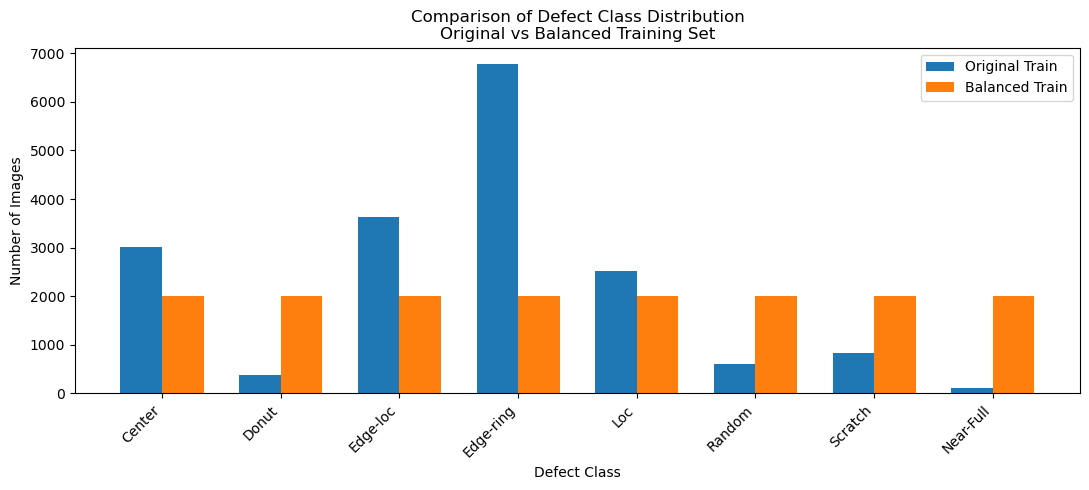

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

# 原始訓練集
train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train"

# 平衡後訓練集
balanced_train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\balanced_train"

classes = [
    'Center','Donut','Edge-loc','Edge-ring','Loc',
    'Random','Scratch','Near-Full']
def count_images(base_dir, classes):
    counts = []
    for cls in classes:
        cls_path = os.path.join(base_dir, cls)
        count = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        ])
        counts.append(count)
    return counts


train_counts = count_images(train_dir, classes)
balanced_counts = count_images(balanced_train_dir, classes)
x = np.arange(len(classes))   # 類別位置
width = 0.35                  # 每根柱子的寬度

plt.figure(figsize=(11, 5))

plt.bar(x - width/2, train_counts, width, label='Original Train')
plt.bar(x + width/2, balanced_counts, width, label='Balanced Train')

plt.xticks(x, classes, rotation=45, ha="right")
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("Comparison of Defect Class Distribution\nOriginal vs Balanced Training Set")
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
import os
import matplotlib.pyplot as plt

# 資料集路徑
base_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\wafer_images_fast"

# 類別
classes = [
    'Center','Donut','Edge-loc','Edge-ring','Loc',
    'Random','Scratch','Near-Full','None'
]

valid_classes = []
counts = []

# 統計
for cls in classes:
    cls_path = os.path.join(base_dir, cls)

    if not os.path.exists(cls_path):
        print(f"⚠️ 找不到資料夾：{cls}")
        continue

    num_images = len([
        f for f in os.listdir(cls_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ])

    valid_classes.append(cls)
    counts.append(num_images)
    print(f"{cls}: {num_images}")

print("\n總圖片數 =", sum(counts))

# ======================
# 繪製長條圖
# ======================
plt.figure(figsize=(12, 5))
plt.bar(valid_classes, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")
plt.title("Distribution of Wafer Defect Classes (wafer_images_fast)")
plt.tight_layout()
plt.show()


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32

# 訓練資料生成器，已包含增強
train_datagen = ImageDataGenerator(rescale=1./255)

# 驗證與測試資料生成器，只做 rescale，不做增強
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\train"
val_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\val"
test_dir = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\dataset\test"

train_set = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_set = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_set = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMAGE_SIZE,
    batch_size=1,
    class_mode='categorical',
    shuffle=False
)

# 下面可接你的模型定義、編譯與訓練程式碼


Found 121062 images belonging to 9 classes.
Found 25942 images belonging to 9 classes.
Found 25946 images belonging to 9 classes.


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_set.classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))
print("Class Weight:", class_weights)


In [65]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64,64,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(train_set.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)

history = model.fit(
    train_set,
    validation_data=val_set,
    epochs=5,
    callbacks=[early_stop, checkpoint, reduce_lr]
)
model.save("best_model.h5")


Epoch 1/5
1775/3784 [=============>................] - ETA: 3:28 - loss: 0.4456 - accuracy: 0.8971

KeyboardInterrupt: 

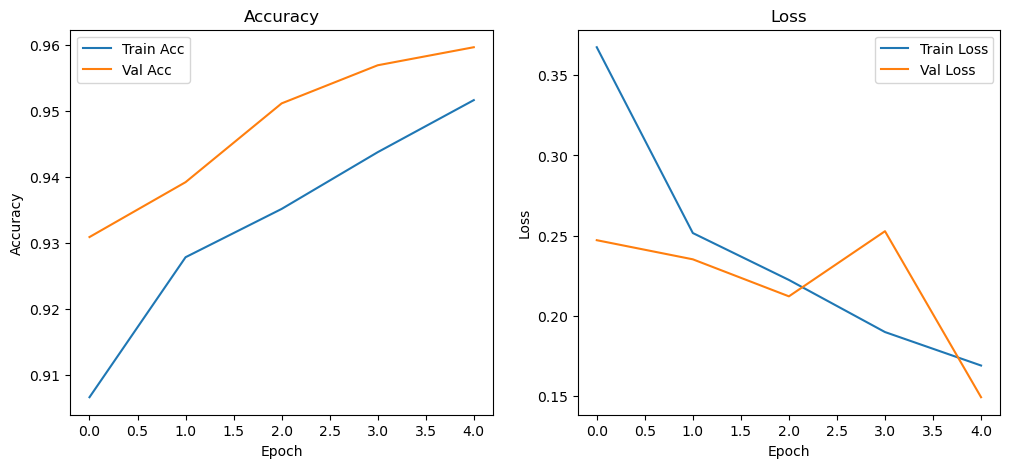

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


25946/25946 [==============================] - 84s 3ms/step


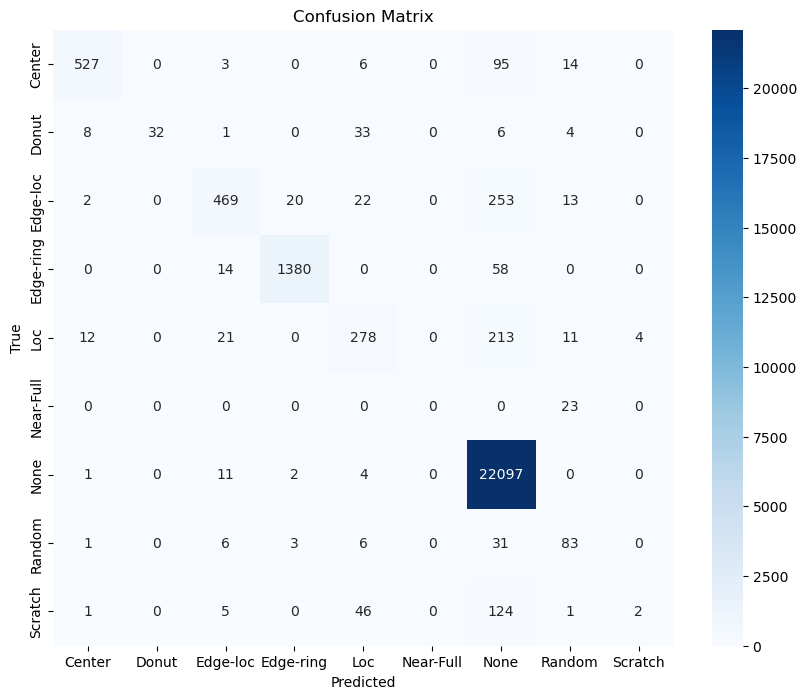

In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

y_true = test_set.classes
y_pred_prob = model.predict(test_set, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=train_set.class_indices.keys(),
            yticklabels=train_set.class_indices.keys(), cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [41]:
report = classification_report(y_true, y_pred, target_names=train_set.class_indices.keys())
print(report)


              precision    recall  f1-score   support

      Center       0.95      0.82      0.88       645
       Donut       1.00      0.38      0.55        84
    Edge-loc       0.88      0.60      0.72       779
   Edge-ring       0.98      0.95      0.97      1452
         Loc       0.70      0.52      0.60       539
   Near-Full       0.00      0.00      0.00        23
        None       0.97      1.00      0.98     22115
      Random       0.56      0.64      0.59       130
     Scratch       0.33      0.01      0.02       179

    accuracy                           0.96     25946
   macro avg       0.71      0.55      0.59     25946
weighted avg       0.95      0.96      0.95     25946



d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\anaconda\lib\site-packages\sklearn\metrics\_classification.py:1318: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [47]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    img_array: shape (1, H, W, 3), float32, range [0,1]
    model: 已訓練 Keras 模型
    last_conv_layer_name: 最後一個 Conv 層名稱
    pred_index: 如果 None, 取最大機率類別
    """
    # 1. 建立 Grad-CAM 模型
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. 計算梯度
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    # 3. 平均 pooling（Global Average Pooling over H x W）
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # 4. 加權 conv_outputs
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # 5. ReLU + normalize
    heatmap = np.maximum(heatmap.numpy(), 0)
    heatmap /= (np.max(heatmap) + 1e-8)
    
    return heatmap


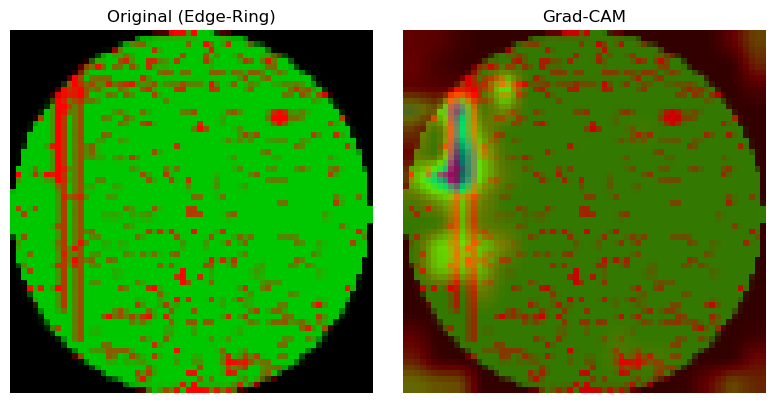

In [64]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model

def get_grad_cam(model, img_array, layer_name=None):
    """
    model: keras model
    img_array: (1, H, W, 3), float32, 已 normalize [0,1]
    layer_name: 最後一層 Conv 層名稱, 如果 None 則自動選
    return: heatmap (H, W)
    """
    if layer_name is None:
        # 自動找到最後一個 Conv2D
        for layer in reversed(model.layers):
            if isinstance(layer, tf.keras.layers.Conv2D):
                layer_name = layer.name
                break
    conv_layer = model.get_layer(layer_name)
    
    grad_model = Model(inputs=model.inputs, outputs=[conv_layer.output, model.output])
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        class_idx = tf.argmax(predictions[0])
        loss = predictions[:, class_idx]

    grads = tape.gradient(loss, conv_outputs)  # 計算梯度
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    
    conv_outputs = conv_outputs[0]  # (H, W, C)
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)
    
    # ReLU + normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()
    
    return heatmap

def overlay_heatmap(img, heatmap, alpha=0.4, colormap=cv2.COLORMAP_JET):
    """
    img: 原圖, uint8 (H, W, 3)
    heatmap: float32, (H, W), range [0,1]
    """
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_color = cv2.applyColorMap(heatmap_uint8, colormap)
    overlay = cv2.addWeighted(img, 1-alpha, heatmap_color, alpha, 0)
    return overlay

# =========================
# 範例使用
# =========================
img_path = r"C:\Users\user\Desktop\MIR-WM811K\MIR-WM811K\Python\wafer_images_fast\Scratch\wafer_007849.png"

# 讀取圖片（BGR）
img_bgr = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# resize 成模型輸入大小
img_resized = cv2.resize(img_rgb, (64, 64))

# normalize（和 ImageDataGenerator rescale=1./255 一樣）
img_input = img_resized.astype("float32") / 255.0
img_input = np.expand_dims(img_input, axis=0)  # (1, 64, 64, 3)
# 計算 Grad-CAM
heatmap = get_grad_cam(model, img_input)

# 疊回原圖（顯示用，uint8）
overlay = overlay_heatmap(img_resized, heatmap)

# 顯示
plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img_resized)
plt.title("Original (Edge-Ring)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(overlay)
plt.title("Grad-CAM")
plt.axis("off")

plt.tight_layout()
plt.show()
